In [1]:
import torch
import matplotlib.pyplot as plt

In [2]:
class Vocab:
    def __init__(self, file):
        self.file = file # for printing
        self.words = set()
        self.texts = []
        self.__process__()

    def __process__(self):

        with open(self.file, 'r', encoding='utf-8') as f:
            for line in f:
                text = []
                for word in line.split():
                    self.words.add(word)
                    text.append(word)
                self.texts.append(text)
        
        self.words = sorted(self.words)

        self.vocab_size = len(self.words)

        self.stoi = { w:i for i,w in enumerate(self.words) }
        self.itos = { i:w for i,w in enumerate(self.words) }


    def encode(self, s):
        return [self.stoi[word] for word in s.split()]

    def decode(self, ids):
        return ' '.join([self.itos[i] for i in ids])


In [3]:
v = Vocab('catsndogs.txt')

In [4]:
print(v.decode(v.encode("the rug slept")))

the rug slept


In [5]:
v.encode(" ".join(v.texts[0]))


[7, 0, 5, 3, 7, 2]

In [6]:
d_model = 20
max_seq_len=15


In [65]:
import numpy as np

class AttentionHead:
    def __init__(self, d_model):
        self.wkey = torch.nn.Parameter(torch.randn(d_model, d_model))
        self.wquery = torch.nn.Parameter(torch.randn(d_model, d_model))
        self.wvalue = torch.nn.Parameter(torch.randn(d_model, d_model))


class Node:
    def __init__(self, head, d_model, data):
        self.data = data
        self.head = head

    def key(self):
        return self.head.wkey @ self.data

    def query(self):
        return self.head.wquery @ self.data

    def value(self):
        return self.head.wvalue @ self.data

class Graph:
    # actually, a DAG
    def __init__(self, data, seq_len, d_model, head):
        self.seq_len  = seq_len
        self.d_model = d_model
        self.head  = head 
        self.nodes = [Node(self.head, self.d_model, data[i]) for i in range(self.seq_len)]

        self.edges = []

        for i in range(self.seq_len):
            self.edges.extend([[j, i] for j in range(i+1)])

    def run(self):
        updates = [None] * self.seq_len

        for i, n in enumerate(self.nodes):
            q = n.query()
            inputs = [self.nodes[ifrom] for (ifrom, ito) in self.edges if ito == i]            
            keys = [m.key() for m in inputs]
            scores = [k.dot(q) / np.sqrt(self.d_model) for k in keys]
            scores = torch.tensor(scores)
            scores = torch.exp(scores-torch.max(scores))
             
            attention = scores/torch.sum(scores)
            values = [m.value() for m in inputs]
            update = sum([a * v for a, v in zip(attention, values)])
            updates[i] = update

        for i,n in enumerate(self.nodes):
            n.data = n.data + updates[i] # residual connection

        return torch.stack([n.data for n in self.nodes])

        

In [66]:
class MinGraphGPT:
    def __init__(self, d_model, vocab_size, max_seq_len=15):

        self.embedding = torch.nn.Embedding(v.vocab_size, d_model)
        self.position_embedding = torch.nn.Embedding(max_seq_len, d_model)

        self.head = AttentionHead(d_model)
        self.d_model = d_model
        self.lin_head = torch.nn.Linear(d_model, vocab_size)

    def run(self, x):
        g = Graph(x, x.shape[0], self.d_model, self.head)
        o = g.run()
        logits = self.lin_head(o)
        return logits

    def infer(self, tprompt_ids):
        tpos_ids = torch.arange(len(prompt_ids))
        prompt_x = self.embedding(tprompt_ids) + self.position_embedding(tpos_ids)
        logits = self.run(prompt_x)
        probs = torch.softmax(logits, dim=-1)
        return probs

    def parameters(self):
        return list(self.embedding.parameters()) + list(self.position_embedding.parameters()) + [self.head.wkey, self.head.wquery, self.head.wvalue]+ list(self.lin_head.parameters())

In [67]:
model = MinGraphGPT(d_model, v.vocab_size)

In [68]:
for p in model.parameters():
    print(p.shape, p.requires_grad)

torch.Size([8, 20]) True
torch.Size([15, 20]) True
torch.Size([20, 20]) True
torch.Size([20, 20]) True
torch.Size([20, 20]) True
torch.Size([8, 20]) True
torch.Size([8]) True


In [69]:
class Trainer:
    def __init__(self, model, v):
        self.model = model
        self.losses = []
        self.v = v
        self.loss_fn = torch.nn.CrossEntropyLoss()
        

    def run(self, n_epoch, lr=1e-3):

        optimizer = torch.optim.AdamW(model.parameters())
        
        for epoch in range(n_epoch):
        
            epoch_loss = 0

            for sent_words in self.v.texts:
        
                optimizer.zero_grad(set_to_none=True)

                sent_ids = [self.v.stoi[word] for word in sent_words]
                tsent_ids = torch.tensor(sent_ids)
                tpos_ids = torch.arange(len(sent_words))        
                x = model.embedding(tsent_ids) + model.position_embedding(tpos_ids)
                logits = model.run(x)
                targets = torch.tensor(sent_ids[1:])
            
                loss = self.loss_fn(logits[:-1], targets)
        
                loss.backward()
                optimizer.step()
                epoch_loss += loss.item()
        
            epoch_loss /= len(v.texts)
            
            self.losses.append(epoch_loss)        

In [70]:
trainer = Trainer(model, v)


In [81]:
trainer.run(300)

Text(0, 0.5, 'Loss')

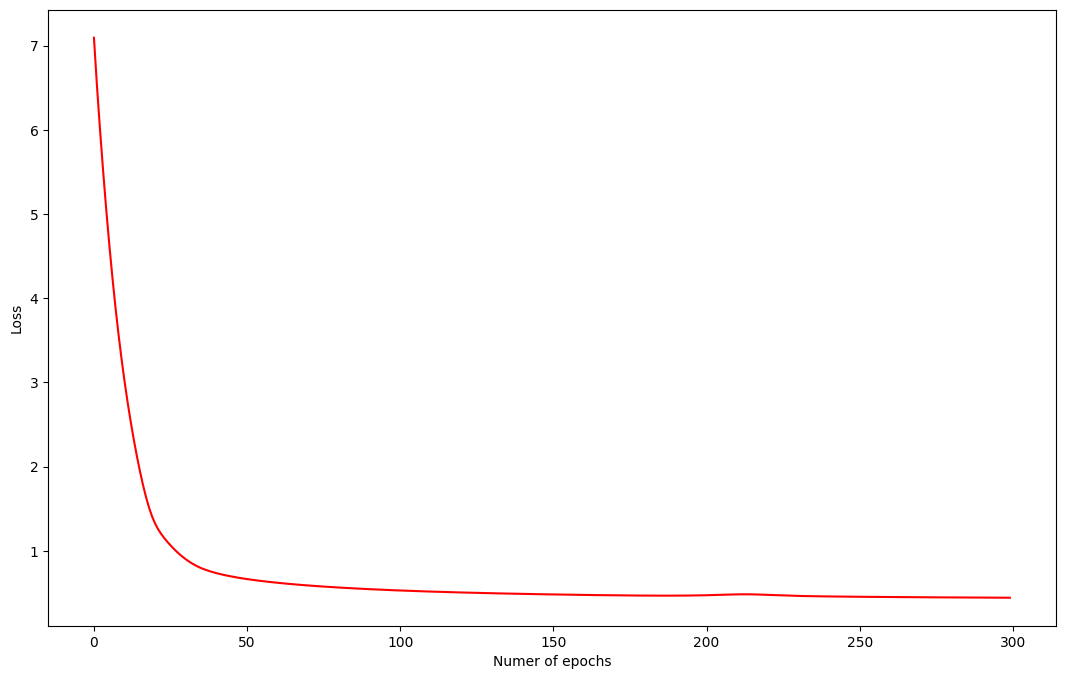

In [82]:
plt.figure(figsize=(13, 8))
plt.plot(range(len(trainer.losses)), trainer.losses, color='red')
plt.xlabel('Numer of epochs')
plt.ylabel('Loss')

In [99]:
prompt = "the dog slept on"
prompt_ids = v.encode(prompt)
tprompt_ids = torch.tensor(prompt_ids)
probs = model.infer(tprompt_ids)


In [100]:
next_probs = probs[-1]

In [101]:
def probs_to_words(probs, vocab):
    pairs = [
        (vocab.itos[i], probs[i].item())
        for i in range(len(probs))
    ]
    return sorted(pairs, key=lambda x: x[1], reverse=True)

In [102]:
next_words  = probs_to_words(next_probs, v)

In [103]:
for word, p in next_words:
    print(f"{word:10s} {p:.4f}")

the        0.9731
rug        0.0196
mat        0.0067
sat        0.0004
cat        0.0002
on         0.0001
dog        0.0000
slept      0.0000


# Relationships example